In [ ]:
# !pip install......

# !pip install pandas numpy matplotlib
# !pip install japanize-matplotlib 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語フォント対応
import seaborn as sns

In [ ]:
# df.to_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv', index=False)
df = pd.read_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv')

In [10]:
import os
import pandas as pd

root_dir = os.getcwd() 
root_dir = os.path.dirname(root_dir)
root_dir


data_file = os.path.join(root_dir,'Data_time_series', 'en_share_over2_monthly.csv')
df_share = pd.read_csv(data_file)

In [11]:
# Filter for rows where Medium (中分類) and Minor (小分類) are '-'
# This isolates the top-level "Major" rows

major_rows = df[ (df['Category level 1'] != '-') & (df['Category level 2'] == '-') & (df['Category level 3'] == '-') ]

major_dict = dict(zip(major_rows['Category level 1'], major_rows['Item']))
print(major_dict['1']) # Output: 食料

hierarchy = {}

# Iterate through every row
for index, row in df.iterrows():
    major_id = row['Category level 1']
    med_id = row['Category level 2']
    min_id = row['Category level 3']
    name = row['Item']

    # Skip header/garbage rows if any
    if major_id == '-': continue 

    # 1. Initialize Major Level
    # We use the ID as the key, but store the Name inside
    if major_id not in hierarchy:
        # Look up the major name from our simple dict
        major_name = major_dict.get(major_id, "他")
        hierarchy[major_id] = {'name': major_name, 'med': {}}

    # 2. Add Medium Level (if this row represents a Medium category or deeper)
    if med_id != '-':
        if med_id not in hierarchy[major_id]['med']:
             # Use the name if this is the defining row, otherwise generic placeholder until found
            hierarchy[major_id]['med'][med_id] = {'name': name, 'small': {}}
        
        # Update name if this is exactly the Medium definition row
        if min_id == '-':
            hierarchy[major_id]['med'][med_id]['name'] = name

    # 3. Add Minor Level (if this row represents a Minor category)
    if min_id != '-':
        # Add the minor category to the medium's children
        hierarchy[major_id]['med'][med_id]['small'][min_id] = name
# Usage:
# hierarchy[1]['children'][1]['name']  -> Access the name of Medium Category 1 inside Major 1
# Initialize the flat dictionary
# Key = Item Name (e.g., 'パン'), Value = Formatted String (e.g., '食料ーパン')

name_to_path_map = {}

# Iterate through the hierarchy
for major_id, major_data in hierarchy.items():
    major_name = major_data['name']
    
    # 1. Add the Major category itself (Optional, if needed)
    # name_to_path_map[major_name] = major_name
    
    # Check if 'med' exists
    if 'med' in major_data:
        for med_id, med_data in major_data['med'].items():
            med_name = med_data['name']
            
            # 2. Add Medium Category: Input '穀類' -> Output '食料ー穀類'
            name_to_path_map[med_name] = f"{major_name}ー{med_name}"
            
            # Check if 'small' exists
            if 'small' in med_data:
                for small_id, small_name in med_data['small'].items():
                    # 3. Add Small Category: Input 'パン' -> Output '食料ーパン'
                    # Note: Using strict user format "Major-Small". 
                    # If you wanted full path "Major-Med-Small", use: f"{major_name}ー{med_name}ー{small_name}"
                    name_to_path_map[small_name] = f"{major_name}ー{med_name}ー{small_name}"

# Check the result
print(name_to_path_map['bread']) 
# Output: '食料ーパン'

def get_category_path(item_name):
    return name_to_path_map.get(item_name, item_name) # Returns "他" if not found

print(get_category_path('bread'))

food
foodーgrainsーbread
foodーgrainsーbread


In [12]:
# --- Step 1: Flatten your hierarchy dictionary ---
# This converts: {'1': {'name': 'food', 'med': {'1': {'name': 'grains', 'small': {'1': 'rice'...
# To: {'rice': 'food', 'bread': 'food', ...}

category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    for l2_id, l2_info in l1_info['med'].items():
        # Option A: Map to Level 1 (Food vs Transport)
        # Option B: Map to Level 2 (Grains vs Meat)
        # Let's map to Level 1 for a high-level systemic view
        for l3_id, l3_name in l2_info['small'].items():
            category_map[l3_name] = l1_name

# Convert to a Series for easy grouping
category_series = pd.Series(category_map)

In [13]:
# Dataframe for 3 levels of category hierarchy

c1 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']=='-') & (df_share['Category level 3']=='-')]

c2 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']=='-')]

c3 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']!='-')]

In [15]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore

def prep_data_for_stl(raw_df: pd.DataFrame, meta_col_count: int = 3) -> pd.DataFrame:
    """
    Cleans raw DataFrame and transposes it into a Time x Items format.
    """
    # 1. Extract and Transpose
    df_ts = raw_df.set_index('Item').iloc[:, meta_col_count:]
    df_t = df_ts.T

    # 2. Index Formatting
    df_t.index = pd.to_datetime(df_t.index)
    df_t = df_t.sort_index()

    # 3. Type Casting & Handle Missing Data (STL requires no NaNs)
    df_t = df_t.astype(np.float64)
    # df_t = df_t.ffill().bfill() # Forward/backward fill any missing percentages
    
    return df_t

def get_residuals(series: pd.Series, period: int = 12) -> pd.Series:
    """
    Extracts the residual component from a time series using STL.
    """
    # robust=True handles outliers (like COVID-19 anomalies) better
    res = STL(series, period=period, robust=True).fit()
    return res.resid


In [ ]:
# --- Execution Pipeline ---

# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c1, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Min-Max Normalization
df_res_norm = df_residuals.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

|                     |     food |   residence |   Utilities/Water |   Furniture/household supplies |   clothing and footwear |   health care |   Transportation/Communication |   education |   educational entertainment |   Other consumption expenditure |
|:--------------------|---------:|------------:|------------------:|-------------------------------:|------------------------:|--------------:|-------------------------------:|------------:|----------------------------:|--------------------------------:|
| 2000-01-01 00:00:00 | 0.410179 |    0.484911 |          0.449561 |                       0.287333 |                0.797492 |      0.575891 |                       0.553131 |    0.478427 |                    0.501358 |                        0.413295 |
| 2000-02-01 00:00:00 | 0.387601 |    0.456422 |          0.489107 |                       0.258839 |                0.749468 |      0.5884   |                       0.584449 |    0.42593  |                    0.533485 |               

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# 1. 提取单列实数信号（减去均值以确保围绕0振荡，虽然你的残差可能已经是0均值了）
x = df_res_norm['food'].values
x_centered = x - np.mean(x)

# 2. Hilbert 变换
z_signal = hilbert(x_centered)
amplitude = np.abs(z_signal)
phase = np.angle(z_signal)
unwrapped_phase = np.unwrap(phase)

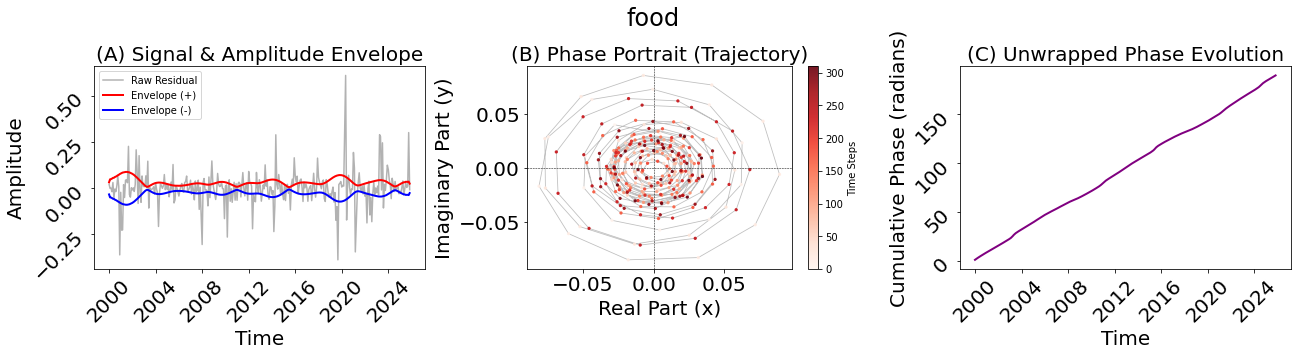

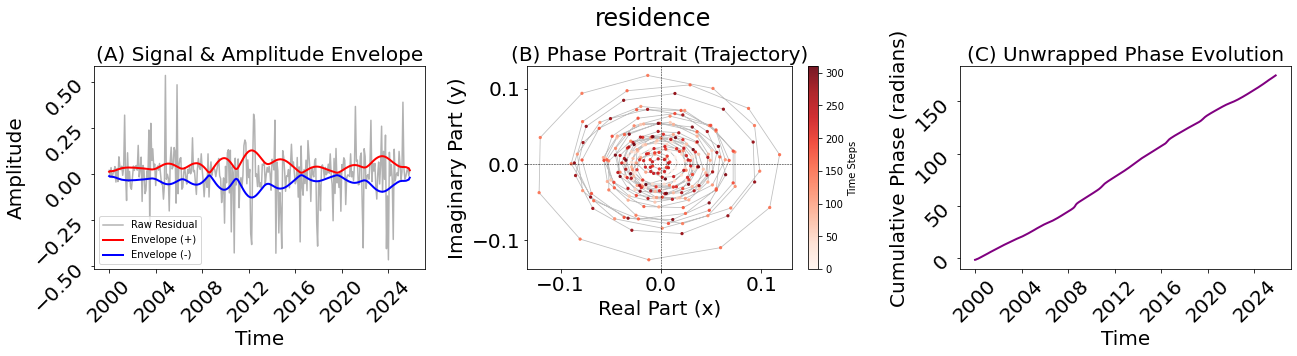

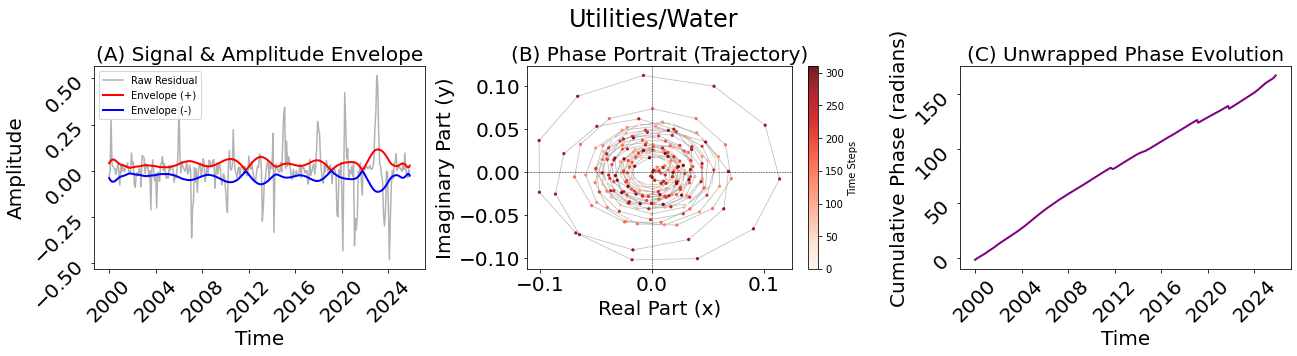

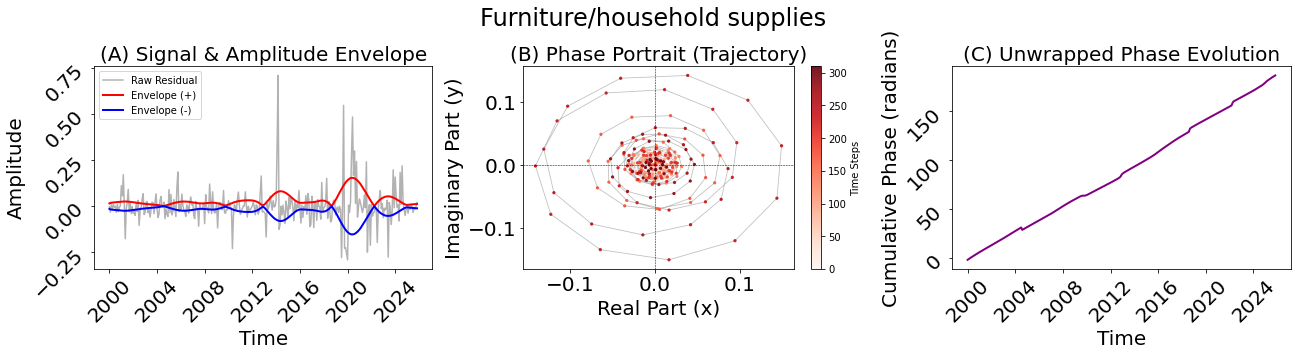

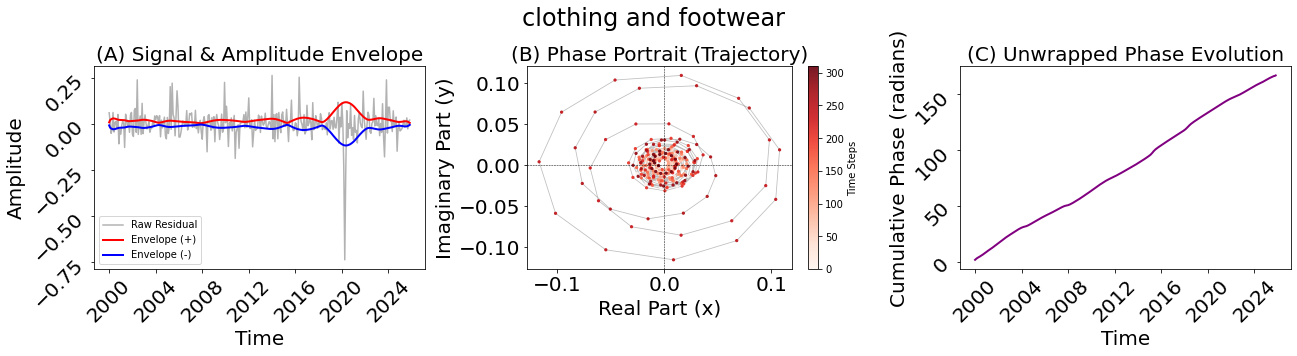

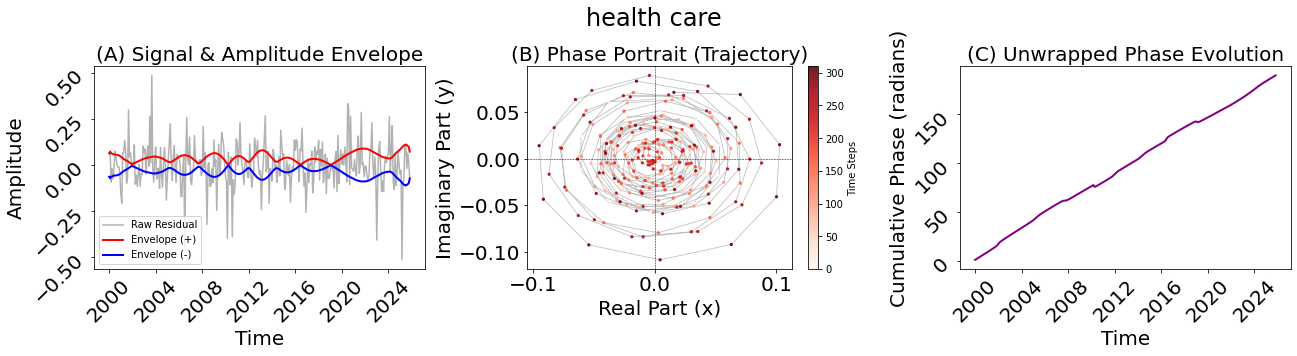

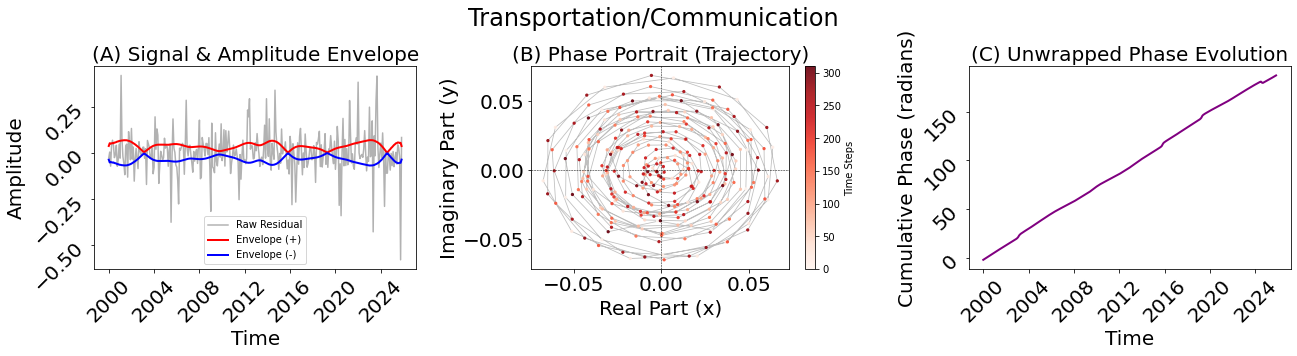

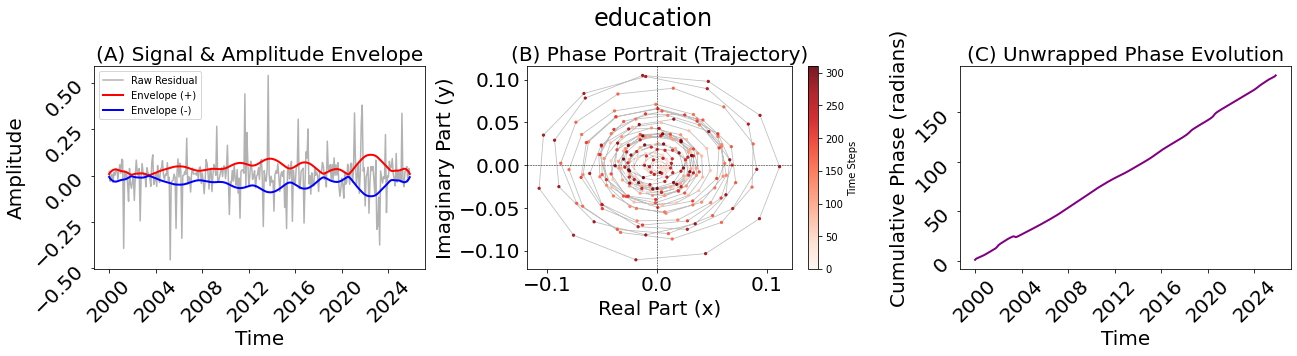

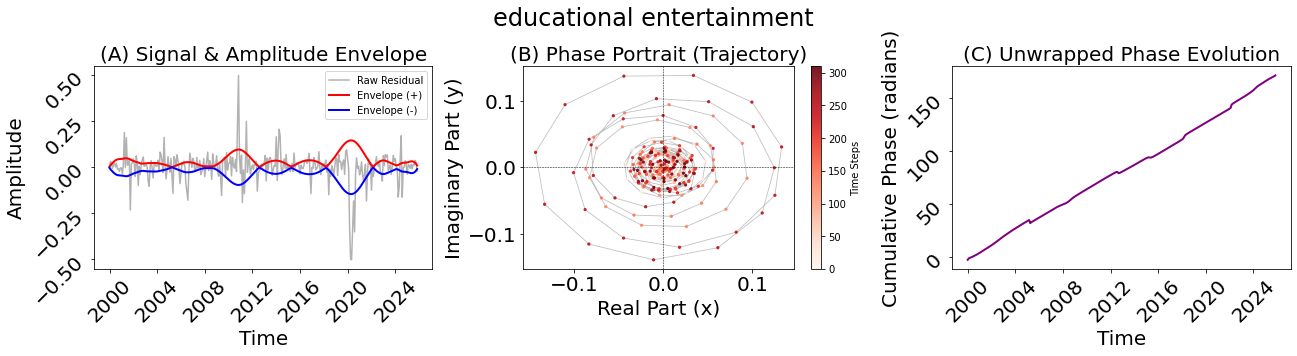

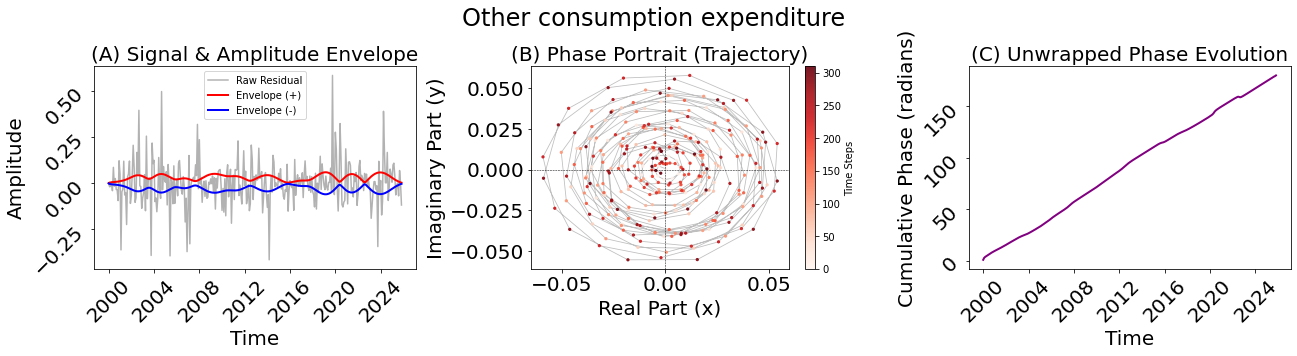

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt

# --- 1. 准备数据 ---

for ca in df_res_norm.columns:
    
    time_axis = df_res_norm.index 
    x_data = df_res_norm[ca].values
    x_centered = x_data - np.mean(x_data)

    # --- 2. 带通滤波 (核心救场步骤！) ---
    # 我们的数据是月度的，采样频率 fs = 1 (1个月1个数据点)
    # 年周期是 12 个月，对应频率是 1/12 = 0.0833
    # 我们设定一个窗口：只放行周期在 9 到 15 个月之间的信号
    fs = 1.0
    lowcut = 1 / 15.0  # 对应 15 个月
    highcut = 1 / 9.0  # 对应 9 个月
    nyq = 0.5 * fs      # 奈奎斯特频率
    low = lowcut / nyq
    high = highcut / nyq

    # 创建一个 4 阶巴特沃斯带通滤波器
    b, a = butter(4, [low, high], btype='band')
    # 使用 filtfilt 进行零相位滤波（保证信号不发生时间平移偏移）
    x_filtered = filtfilt(b, a, x_centered)

    # --- 3. 对【滤波后的数据】进行 Hilbert 变换 ---
    z_signal = hilbert(x_filtered)
    amplitude = np.abs(z_signal)
    phase = np.angle(z_signal)
    unwrapped_phase = np.unwrap(phase)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(ca, fontsize=24)
    # --- 图 A: 振幅包络 ---
    axes[0].plot(time_axis, x_centered, label='Raw Residual', color='gray', alpha=0.6)
    axes[0].plot(time_axis, amplitude, label='Envelope (+)', color='red', linewidth=2)
    axes[0].plot(time_axis, -amplitude, label='Envelope (-)', color='blue', linewidth=2)
    axes[0].set_title('(A) Signal & Amplitude Envelope', fontsize=20)
    axes[0].set_xlabel('Time', fontsize=20)
    axes[0].set_ylabel('Amplitude', fontsize=20)
    axes[0].tick_params(axis='both', labelsize=20)
    axes[0].tick_params(rotation=45)
    axes[0].legend(loc='best')

    # --- 图 B: 极限环相图 (带轨迹连线) ---
    # 1. 先画一条灰色的细线，把所有点按时间顺序连起来，展示“转圈”的轨迹
    axes[1].plot(np.real(z_signal), np.imag(z_signal), 
                color='gray', linewidth=0.8, alpha=0.5, zorder=1)

    # 2. 保留原来的散点，用颜色表示时间先后，叠加在连线上
    scatter = axes[1].scatter(np.real(z_signal), np.imag(z_signal), 
                            c=np.arange(len(z_signal)), cmap='Reds', 
                            s=5, alpha=0.9, zorder=2)

    axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
    axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')
    axes[1].set_title('(B) Phase Portrait (Trajectory)', fontsize=20)
    axes[1].set_xlabel('Real Part (x)', fontsize=20)
    axes[1].set_ylabel('Imaginary Part (y)', fontsize=20)
    axes[1].tick_params(axis='both', labelsize=20)
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Time Steps')

    # --- 图 C: 累积相位 ---
    axes[2].plot(time_axis, unwrapped_phase, color='purple', linewidth=2)
    axes[2].set_title('(C) Unwrapped Phase Evolution', fontsize=20)
    axes[2].set_xlabel('Time', fontsize=20)
    axes[2].set_ylabel('Cumulative Phase (radians)', fontsize=20)
    axes[2].tick_params(axis='both', labelsize=20)
    axes[2].tick_params(rotation=45)
    plt.tight_layout()
    plt.show()


food


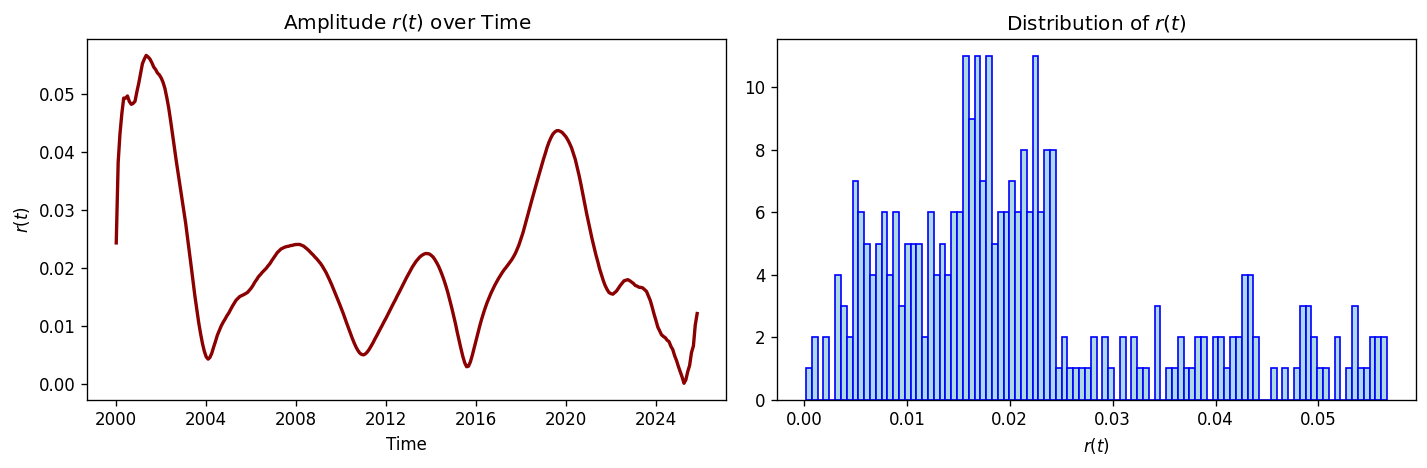

Angular frequency ω ≈ 0.5006 rad/month
Period ≈ 12.55 months
R² = 0.9990

residence


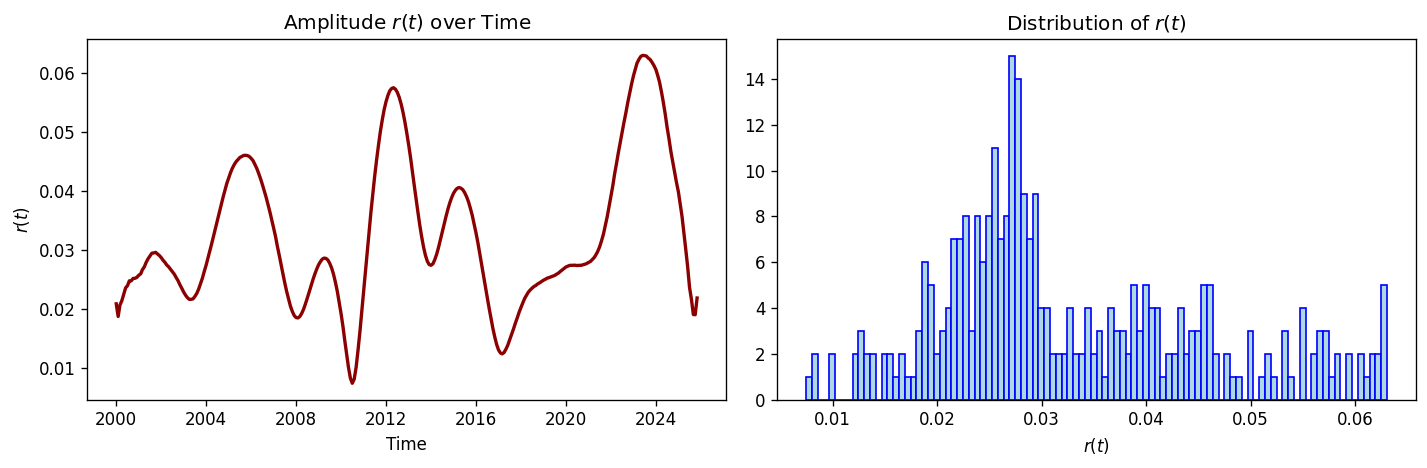

Angular frequency ω ≈ 0.5309 rad/month
Period ≈ 11.83 months
R² = 0.9971

Utilities/Water


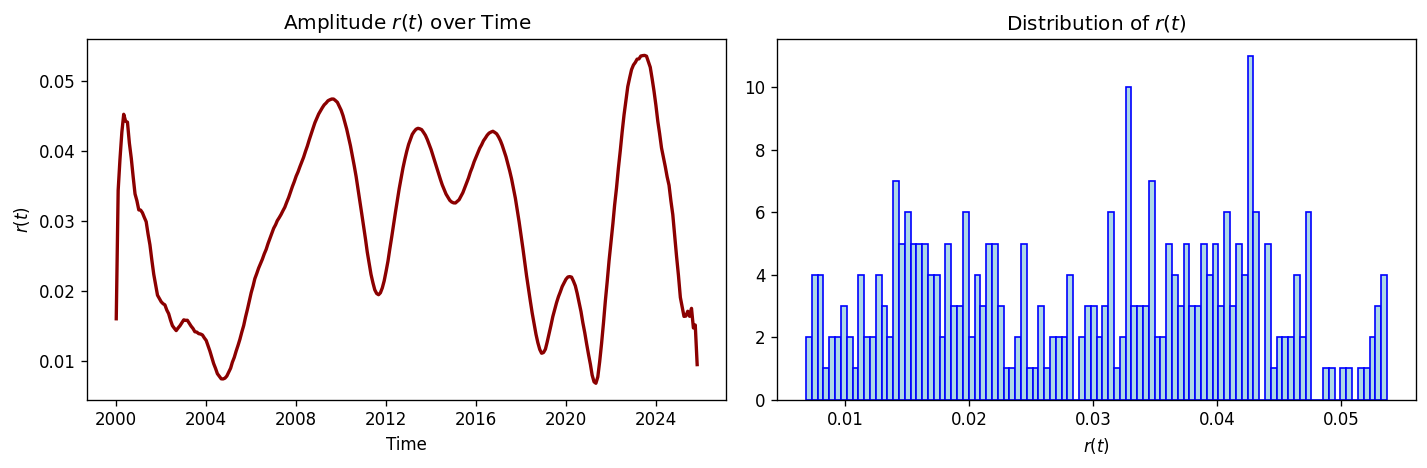

Angular frequency ω ≈ 0.5421 rad/month
Period ≈ 11.59 months
R² = 0.9988

Furniture/household supplies


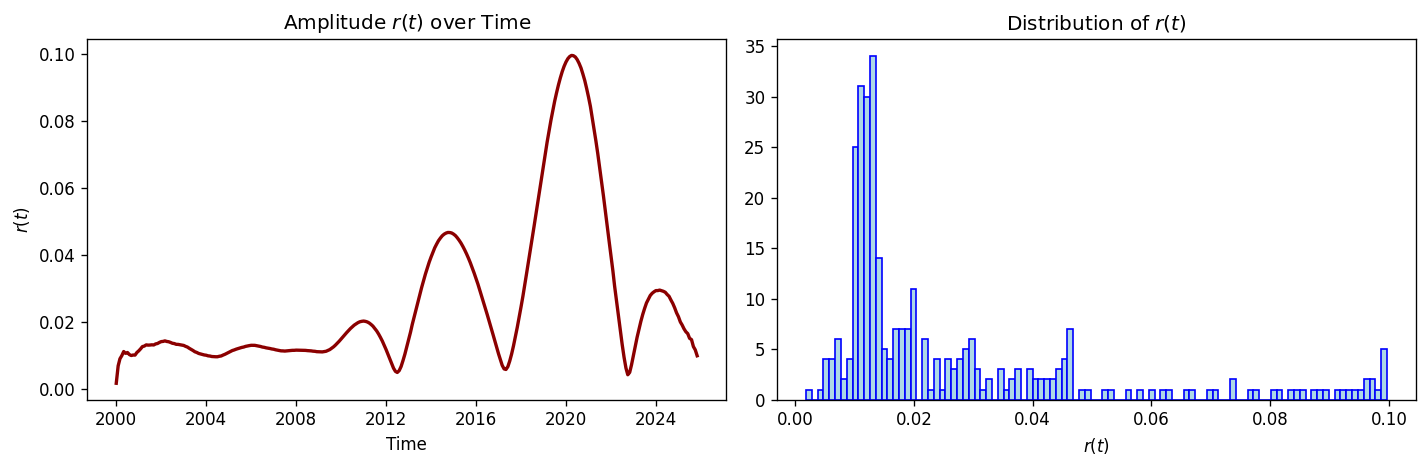

Angular frequency ω ≈ 0.5023 rad/month
Period ≈ 12.51 months
R² = 0.9991

clothing and footwear


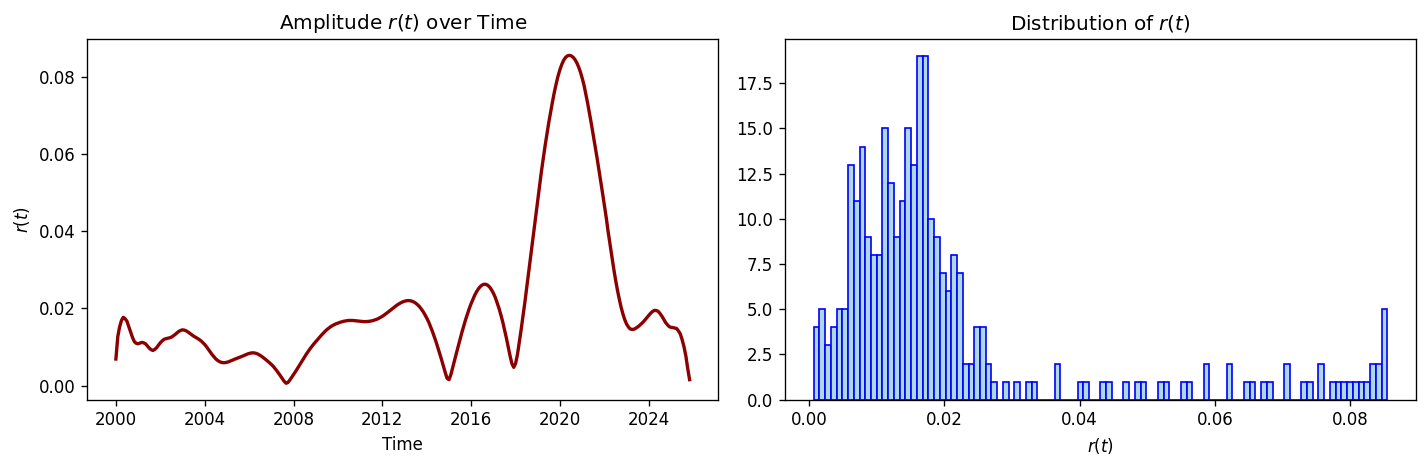

Angular frequency ω ≈ 0.5106 rad/month
Period ≈ 12.31 months
R² = 0.9990

health care


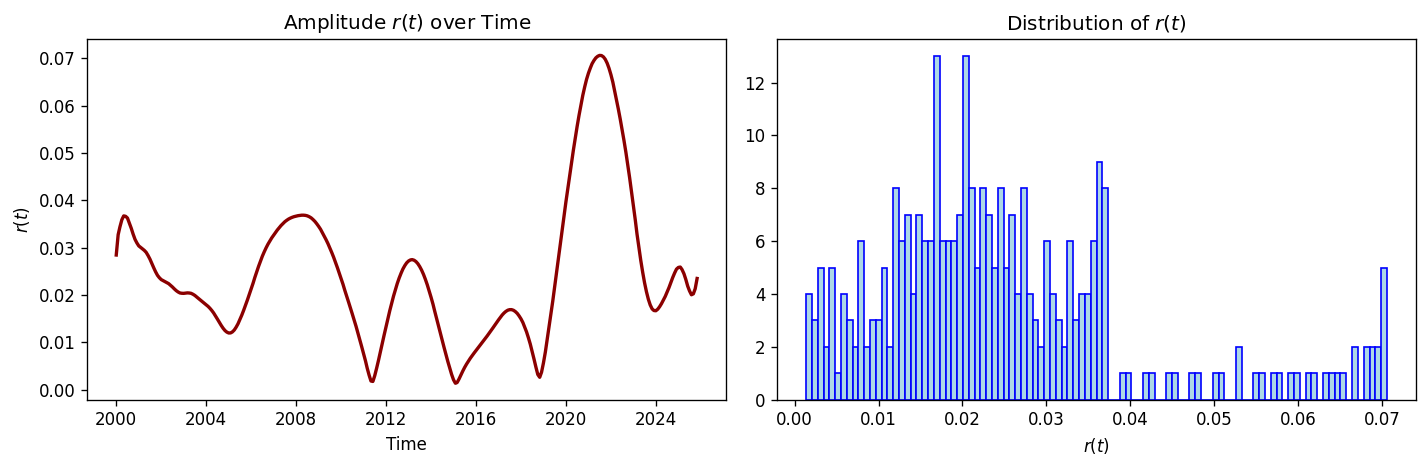

Angular frequency ω ≈ 0.5292 rad/month
Period ≈ 11.87 months
R² = 0.9992

Transportation/Communication


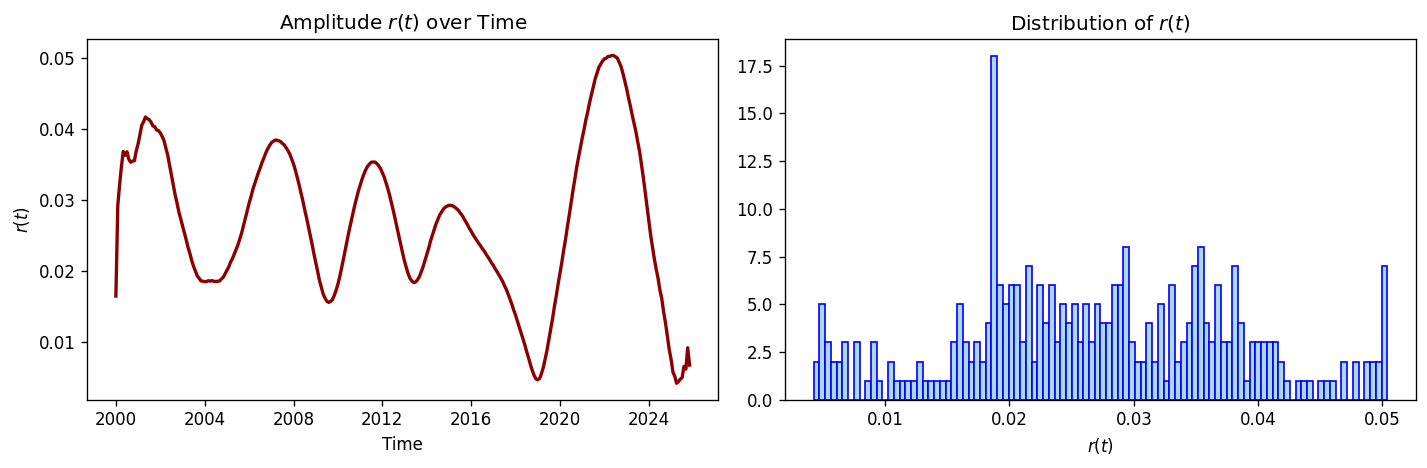

Angular frequency ω ≈ 0.5546 rad/month
Period ≈ 11.33 months
R² = 0.9993

education


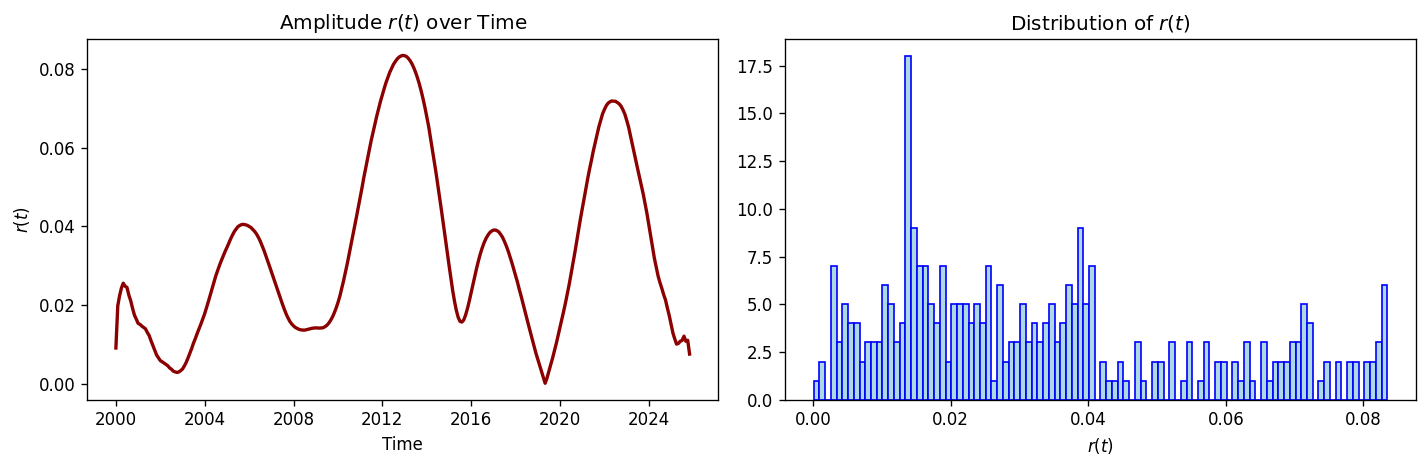

Angular frequency ω ≈ 0.5576 rad/month
Period ≈ 11.27 months
R² = 0.9986

educational entertainment


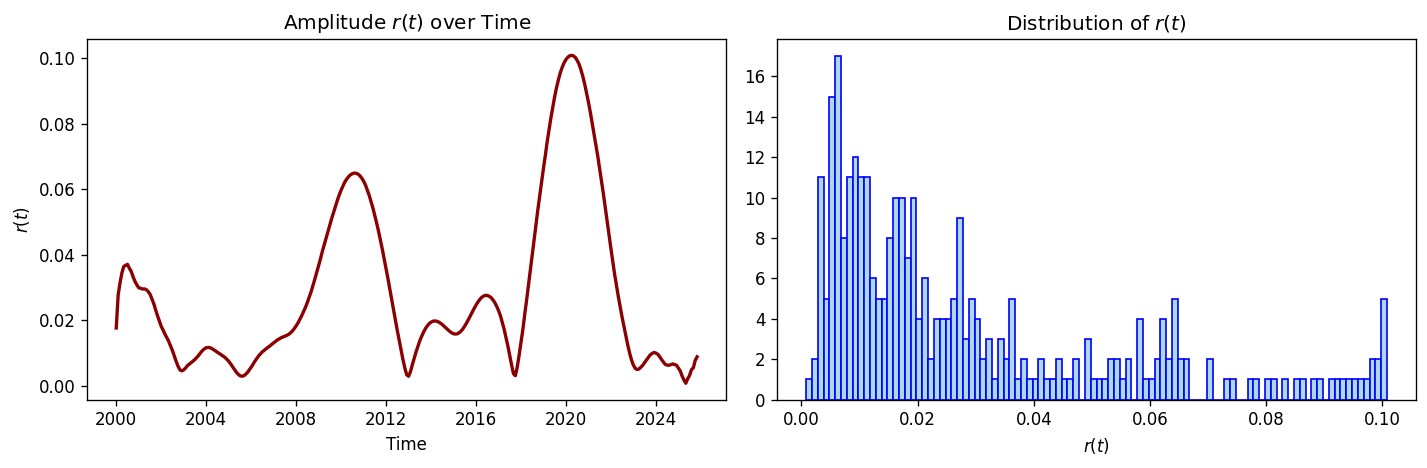

Angular frequency ω ≈ 0.4952 rad/month
Period ≈ 12.69 months
R² = 0.9981

Other consumption expenditure


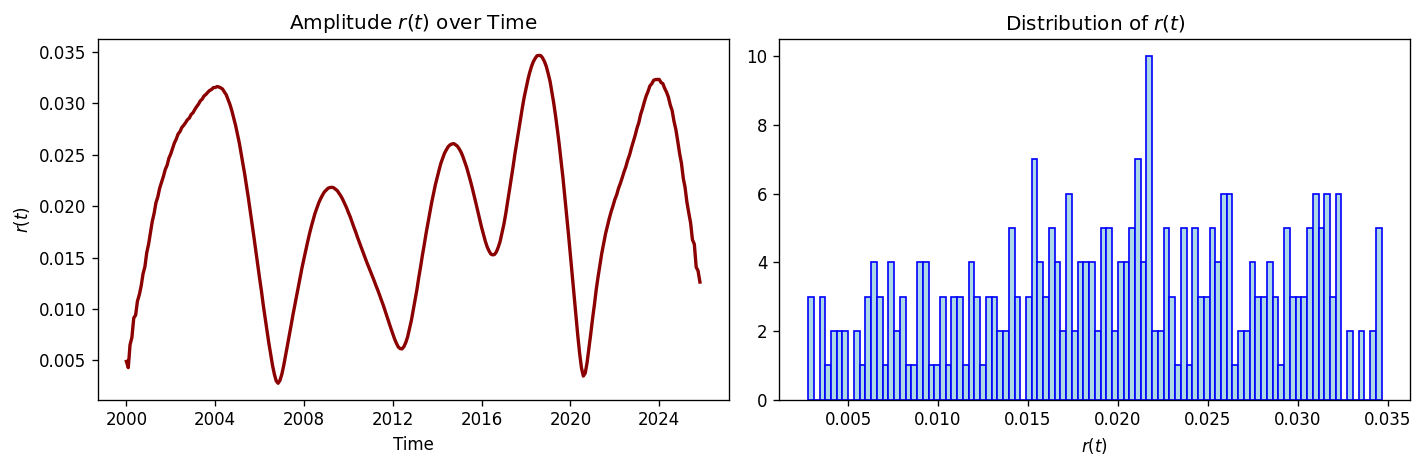

Angular frequency ω ≈ 0.5102 rad/month
Period ≈ 12.31 months
R² = 0.9993


In [86]:
from scipy.stats import linregress
for ca in df_res_norm.columns:
    print(f"\n{ca}")
    time_axis = df_res_norm.index 
    x_data = df_res_norm[ca].values
    x_centered = x_data - np.mean(x_data)

    # --- 2. 带通滤波 (核心救场步骤！) ---
    # 我们的数据是月度的，采样频率 fs = 1 (1个月1个数据点)
    # 年周期是 12 个月，对应频率是 1/12 = 0.0833
    # 我们设定一个窗口：只放行周期在 9 到 15 个月之间的信号
    fs = 1.0
    lowcut = 1/14.0
    highcut = 1/10.0
    nyq = 0.5 * fs      # 奈奎斯特频率
    low = lowcut / nyq
    high = highcut / nyq

    # 创建一个 4 阶巴特沃斯带通滤波器
    b, a = butter(4, [low, high], btype='band')
    # 使用 filtfilt 进行零相位滤波（保证信号不发生时间平移偏移）
    x_filtered = filtfilt(b, a, x_centered)

    # --- 3. 对【滤波后的数据】进行 Hilbert 变换 ---
    z_signal = hilbert(x_filtered)
    amplitude = np.abs(z_signal)
    phase = np.angle(z_signal)
    unwrapped_phase = np.unwrap(phase)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)
    axes[0].plot(time_axis, amplitude, color='darkred', linewidth=2)
    axes[0].set_title('Amplitude $r(t)$ over Time')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('$r(t)$')

    axes[1].hist(amplitude[~np.isnan(amplitude)], bins=100, 
                color='lightblue', edgecolor='blue')
    axes[1].set_title('Distribution of $r(t)$')
    axes[1].set_xlabel('$r(t)$')
    plt.tight_layout()
    plt.show()

    t_idx = np.arange(len(unwrapped_phase))
    valid = ~np.isnan(unwrapped_phase)
    slope, intercept, r_value, _, _ = linregress(t_idx[valid], unwrapped_phase[valid])
    print(f"Angular frequency ω ≈ {slope:.4f} rad/month")
    print(f"Period ≈ {2*np.pi/slope:.2f} months")
    print(f"R² = {r_value**2:.4f}")